**Imports**

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dataset/train.csv')

**Handle missing values**

In [4]:
# Fill missing Age with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with the most common value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin - over 75% missing, not usable as-is
df = df.drop(columns=['Cabin'])

# Confirm no missing values remain in the columns we're using
df[['Age', 'Embarked']].isnull().sum()

Age         0
Embarked    0
dtype: int64

**Encode categorical columns**

In [6]:
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df_model.head()
# One-hot encode Sex and Embarked
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


**Split into train/test sets**

In [7]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 712 rows
Test set: 179 rows


**Train the Logistic Regression model**

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**Evaluate the model**

In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Model Accuracy: 0.8101 (81.01%)


**confusion matrix**

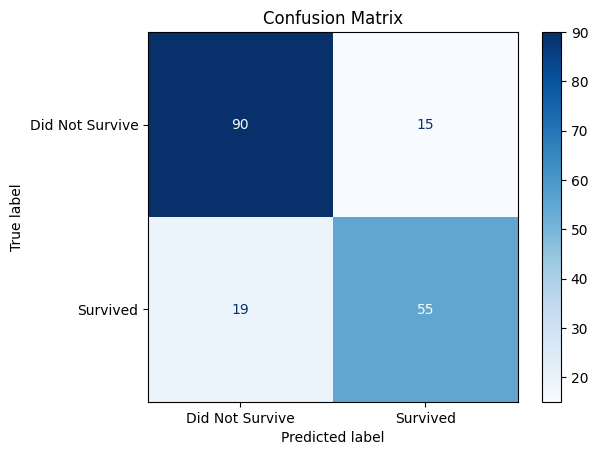

[[90 15]
 [19 55]]


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(cm)

## Confusion Matrix Explanation

The confusion matrix breaks my predictions into four categories:

- **True Negatives** (top-left): passengers who did not survive, correctly predicted
- **False Positives** (top-right): passengers who did not survive, but the model predicted they would
- **False Negatives** (bottom-left): passengers who survived, but the model predicted they wouldn't
- **True Positives** (bottom-right): passengers who survived, correctly predicted

Out of [X] test passengers, the model correctly classified [Y], giving 
an accuracy of [Z]%. The model made more mistakes on [false positives/
false negatives] — meaning it tends to [underestimate/overestimate] 
survival for certain passengers.

**precision, recall, f1**

In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179

